# SkateFormer brakujacy sweep: Cross-View, W=64, S=8

W (`PKU_window_sweep_xsub_xview_ram.ipynb`) zabrakło
punktu **Cross-View, W=64, S=8** w tabeli

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone -q https://github.com/KAIST-VICLab/SkateFormer.git /content/SkateFormer
print('Repozytorium sklonowane')

Mounted at /content/drive
Repozytorium sklonowane


In [ ]:
import os, sys
os.chdir('/content/SkateFormer')

#Poprawka torchlight
with open('/content/SkateFormer/torchlight/torchlight/__init__.py', 'w') as f:
    f.write('''import argparse

class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)

class IO:
    pass
''')
print('Zastosowano poprawkę torchlight.')

#Usunięcie konfliktu z zainstalowaną wersją torchlight
os.system('pip uninstall torchlight -y')
if 'torchlight' in sys.modules:
    del sys.modules['torchlight']
sys.path.insert(0, '/content/SkateFormer/torchlight')
print('Usunięto konflikt z systemowym torchlight.')

#Poprawka main.py
with open('/content/SkateFormer/main.py', 'r') as f:
    content = f.read()
content = content.replace(
    'from torchlight import DictAction',
    '''class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)'''
)
content = content.replace('default_arg = yaml.load(f)',
                          'default_arg = yaml.load(f, Loader=yaml.SafeLoader)')
with open('/content/SkateFormer/main.py', 'w') as f:
    f.write(content)
print('Zastosowano poprawkę main.py.')

#Zastąpienie przestarzałego np.int
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'r') as f:
    content = f.read()
content = content.replace('.astype(np.int)', '.astype(int)')
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzały typ np.int.')

#Zastąpienie przestarzałych typów NumPy
with open('/content/SkateFormer/feeders/tools.py', 'r') as f:
    content = f.read()
for old, new in [('np.int)', 'int)'), ('np.int,', 'int,'),
                 ('np.float)', 'float)'), ('np.float,', 'float,'),
                 ('np.bool)', 'bool)'), ('np.complex)', 'complex)')]:
    content = content.replace(old, new)
with open('/content/SkateFormer/feeders/tools.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzałe typy NumPy.')

print('\nZakończono dostosowanie kodu SkateFormer.')

Zastosowano poprawkę torchlight.
Usunięto konflikt z systemowym torchlight.
Zastosowano poprawkę main.py.
Zastąpiono przestarzały typ np.int.
Zastąpiono przestarzałe typy NumPy.

Zakończono dostosowanie kodu SkateFormer.


In [ ]:
import os, json, shutil
import numpy as np

DRIVE_ROOT    = '/content/drive/MyDrive/PKU_data'
DRIVE_WEIGHTS = '/content/drive/MyDrive/SkateFormer_weights/ntu60_CSub/SkateFormer_j.pt'
LOCAL_DATA    = '/content/SkateFormer/data/ntu'
LOCAL_WEIGHTS = '/content/SkateFormer/SkateFormer_j.pt'
OFFICIAL_CFG  = '/content/SkateFormer/config/test/ntu_cs/SkateFormer_j.yaml'
WORK_DIR_ROOT = '/content/SkateFormer/work_dir/pku_sweep'

SPLIT_DIRS = {'xsub': f'{DRIVE_ROOT}/sweep', 'xview': f'{DRIVE_ROOT}/sweep_xview'}

SWEEP_W = [(32, 8), (64, 16), (96, 24), (128, 32)]
W_BEST  = 64
SWEEP_S = [(W_BEST, 8), (W_BEST, 32)]

os.makedirs(LOCAL_DATA, exist_ok=True)
os.makedirs(WORK_DIR_ROOT, exist_ok=True)

shutil.copy(DRIVE_WEIGHTS, LOCAL_WEIGHTS)
print(f'Wagi: {os.path.getsize(LOCAL_WEIGHTS)/1024**2:.1f} MB')

TARGET_SPLIT = 'xview'
d = SPLIT_DIRS[TARGET_SPLIT]
assert os.path.exists(f'{d}/ground_truth.json'), f'Brak {d}/ground_truth.json na Drive.'

with open(f'{d}/ground_truth.json') as f:
    gt_xview = json.load(f)
with open(f'{d}/seq_lengths.json') as f:
    seq_len_xview = json.load(f)

n_remap = 0
for sid in gt_xview:
    for inst in gt_xview[sid]:
        if inst[0] == 56:
            inst[0] = 24; n_remap += 1
n_seg = sum(len(v) for v in gt_xview.values())
print(f'CROSS-VIEW: {len(gt_xview)} sekwencji, {n_seg} segmentow GT, remap 56->24: {n_remap}')

Wagi: 13.9 MB
CROSS-VIEW: 359 sekwencji, 7141 segmentow GT, remap 56->24: 308


In [ ]:
import pickle, yaml

def run_inference(split, W, S, force=False):
    drive_sweep = SPLIT_DIRS[split]
    src_npz  = f'{drive_sweep}/PKU_windows_test_W{W}_S{S}.npz'
    dst_npz  = f'{LOCAL_DATA}/PKU_win_buf_{split}_W{W}_S{S}.npz'
    work_dir = f'{WORK_DIR_ROOT}/{split}_W{W}_S{S}'
    cache_dir = f'{drive_sweep}/scores/W{W}_S{S}'
    os.makedirs(work_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    assert os.path.exists(src_npz), (
        f'Brak pliku okien: {src_npz}\n'
    )

    data = np.load(src_npz)
    n = data['x_test'].shape[0]
    meta = {'seq_id': data['seq_id'], 'start': data['start'],
            'end': data['end'], 'y_ref': data['y_ref']}

    if not os.listdir(work_dir) and os.listdir(cache_dir):
        for f_ in os.listdir(cache_dir):
            shutil.copy(f'{cache_dir}/{f_}', f'{work_dir}/{f_}')
        print('Przywrocono score.pkl z Drive')

    existing = [p for p in os.listdir(work_dir) if p.endswith('score.pkl')]
    if existing and not force:
        print('wyniki juz zapisane')
    else:

        x_buf = np.zeros((n, W + 1, 150), dtype=np.float32)
        x_buf[:, :W, :] = data['x_test']
        y_test = data['y_test']
        del data
        import gc; gc.collect()
        np.savez(dst_npz, x_test=x_buf, y_test=y_test)
        print(f'Bufor: (N, {W}, 150) -> {x_buf.shape}')
        del x_buf; gc.collect()

        with open(OFFICIAL_CFG) as f:
            cfg = yaml.safe_load(f)
        cfg['work_dir']   = work_dir
        cfg['weights']    = LOCAL_WEIGHTS
        cfg['phase']      = 'test'
        cfg['save_score'] = True
        cfg['test_feeder_args']['data_path'] = dst_npz
        cfg['test_feeder_args']['split']     = 'test'
        cfg_path = f'{work_dir}/config.yaml'
        with open(cfg_path, 'w') as f:
            yaml.dump(cfg, f)

        !cd /content/SkateFormer && python main.py --config "{cfg_path}"

        existing = [p for p in os.listdir(work_dir) if p.endswith('score.pkl')]
        assert existing, f'Brak score.pkl w {work_dir} — main.py sie wywalil?'
        shutil.copy(f'{work_dir}/{existing[0]}', f'{cache_dir}/{existing[0]}')
        os.remove(dst_npz)

    with open(f'{work_dir}/{existing[0]}', 'rb') as f:
        scores = pickle.load(f)
    assert len(scores) == n, f'{len(scores)} wynikow vs {n} okien!'
    logits = np.array([scores[f'test_{i}'] for i in range(n)])
    return logits, meta

print('run_inference gotowe.')

run_inference gotowe.


In [ ]:
from collections import defaultdict

INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
MIN_SEG_LEN = 8
NMS_IOU = 0.3
CONF_TH = 0.0

def build_frame_level(logits, meta, seq_lengths, conf_th=CONF_TH):
    p = np.exp(logits - logits.max(axis=1, keepdims=True))
    p /= p.sum(axis=1, keepdims=True)
    fp = {s: np.zeros((T, 60)) for s, T in seq_lengths.items()}
    fc = {s: np.zeros(T) for s, T in seq_lengths.items()}
    for i in range(len(meta['seq_id'])):
        s = str(meta['seq_id'][i])
        st, en = int(meta['start'][i]), int(meta['end'][i])
        fp[s][st:en] += p[i]; fc[s][st:en] += 1
    pred, avg_all = {}, {}
    for s, T in seq_lengths.items():
        avg = fp[s] / np.maximum(fc[s], 1)[:, None]
        pr = np.argmax(avg, 1); cf = np.max(avg, 1)
        pr[cf < conf_th] = -1
        pr[fc[s] == 0] = -1
        pred[s] = pr; avg_all[s] = avg
    return pred, avg_all, fc

def frames_to_segments(pred, prob_avg):
    segs = []; T = len(pred); t = 0
    while t < T:
        c = pred[t]
        if c < 0:
            t += 1; continue
        st = t
        while t < T and pred[t] == c:
            t += 1
        if t - st >= MIN_SEG_LEN:
            segs.append((int(c), st, t, float(prob_avg[st:t, c].mean())))
    return segs

def iou_1d(a, b):
    s = max(a[0], b[0]); e = min(a[1], b[1]); inter = max(0, e - s)
    u = (a[1] - a[0]) + (b[1] - b[0]) - inter
    return inter / u if u > 0 else 0.0

def nms_segments(segs, iou_th=NMS_IOU):
    segs = sorted(segs, key=lambda x: x[3], reverse=True); keep = []
    while segs:
        b = segs.pop(0); keep.append(b)
        segs = [x for x in segs
                if not (x[0] == b[0] and iou_1d((x[1], x[2]), (b[1], b[2])) > iou_th)]
    return keep

def compute_ap(pred_list, gt_list, iou_th):
    if len(gt_list) == 0:
        return None
    preds = sorted(pred_list, key=lambda x: x[3], reverse=True)
    matched = set(); tp = np.zeros(len(preds)); fp_ = np.zeros(len(preds))
    for i, (seq, st, en, sc) in enumerate(preds):
        bi, bj = 0, -1
        for j, (gs, gst, gen) in enumerate(gt_list):
            if gs != seq or (seq, j) in matched:
                continue
            v = iou_1d((st, en), (gst, gen))
            if v > bi:
                bi, bj = v, j
        if bi >= iou_th:
            tp[i] = 1; matched.add((seq, bj))
        else:
            fp_[i] = 1
    tpc = np.cumsum(tp); fpc = np.cumsum(fp_)
    rec = tpc / len(gt_list); prec = tpc / np.maximum(tpc + fpc, 1e-9)
    mrec = np.concatenate([[0], rec, [1]]); mpre = np.concatenate([[0], prec, [0]])
    for k in range(len(mpre) - 2, -1, -1):
        mpre[k] = max(mpre[k], mpre[k + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def evaluate(logits, meta, seq_lengths, gt_segments, conf_th=CONF_TH,
             iou_list=(0.1, 0.3, 0.5), classes=None):
    pred, avg_all, fc = build_frame_level(logits, meta, seq_lengths, conf_th)
    pred_by_cls = defaultdict(list)
    for s in seq_lengths:
        for (c, st, en, sc) in nms_segments(frames_to_segments(pred[s], avg_all[s])):
            pred_by_cls[c].append((s, st, en, sc))
    gt_by_cls = defaultdict(list)
    for s, segs in gt_segments.items():
        T = seq_lengths[s]
        for (c, st, en) in segs:
            st, en = max(0, st), min(T, en)
            if en > st:
                gt_by_cls[c].append((s, st, en))
    if classes is not None:
        gt_by_cls = {c: v for c, v in gt_by_cls.items() if c in classes}
    results = {}
    for iou in iou_list:
        aps = {}
        for c in gt_by_cls:
            ap = compute_ap(pred_by_cls.get(c, []), gt_by_cls[c], iou)
            if ap is not None:
                aps[c] = ap
        results[iou] = {'mAP': float(np.mean(list(aps.values()))) if aps else 0.0,
                        'per_class': aps}
    return results, pred_by_cls, gt_by_cls

def frame_level_accuracy(logits, meta, seq_lengths, gt_segments,
                         conf_th=CONF_TH, classes=None):
    pred, _, _ = build_frame_level(logits, meta, seq_lengths, conf_th)
    ca = ta = 0
    for s, T in seq_lengths.items():
        g = -np.ones(T, int)
        for (c, st, en) in gt_segments[s]:
            if classes is not None and c not in classes:
                continue
            g[max(0, st):min(T, en)] = c
        mk = g >= 0; p = pred[s]
        ca += (p[mk] == g[mk]).sum(); ta += mk.sum()
    return ca / ta if ta else 0.0

print('Funkcje detekcji gotowe (MIN_SEG_LEN=8, NMS IoU=0.3, AP all-points).')

Funkcje detekcji gotowe (MIN_SEG_LEN=8, NMS IoU=0.3, AP all-points).


In [ ]:
import pandas as pd

RESULTS_CSV = f'{DRIVE_ROOT}/sweep_results.csv'
PCT_COLS = ['frame_acc', 'mAP@0.1', 'mAP@0.3', 'mAP@0.5',
            'frame_acc_inter', 'mAP@0.1_inter', 'mAP@0.3_inter', 'mAP@0.5_inter']

assert os.path.exists(RESULTS_CSV), (
    f'Brak pliu {RESULTS_CSV}'
)
df_prev = pd.read_csv(RESULTS_CSV)
print(f'Wczytano {len(df_prev)} wynikow')
print(df_prev[['split', 'W', 'S']].to_string(index=False))

hit = df_prev[(df_prev['split'] == 'xview') & (df_prev['W'] == 64) & (df_prev['S'] == 8)]

if len(hit):
    print('\nCross-View W=64 S=8 już jest tabeli')
    df = df_prev.copy()
else:
    print('\nBrak wyniku Cross-View W=64 S=8')
    split, W, S = 'xview', 64, 8
    gt, seq_len = gt_xview, seq_len_xview

    logits, meta = run_inference(split, W, S)

    res, pred_by_cls, _ = evaluate(logits, meta, seq_len, gt)
    facc = frame_level_accuracy(logits, meta, seq_len, gt)
    res_i, _, _ = evaluate(logits, meta, seq_len, gt, classes=INTERACTION_NTU)
    facc_i = frame_level_accuracy(logits, meta, seq_len, gt, classes=INTERACTION_NTU)

    new_row = {'split': split, 'W': W, 'S': S, 'n_windows': len(logits),
               'n_detekcji': sum(len(v) for v in pred_by_cls.values()),
               'frame_acc': facc,
               'mAP@0.1': res[0.1]['mAP'], 'mAP@0.3': res[0.3]['mAP'],
               'mAP@0.5': res[0.5]['mAP'],
               'frame_acc_inter': facc_i,
               'mAP@0.1_inter': res_i[0.1]['mAP'], 'mAP@0.3_inter': res_i[0.3]['mAP'],
               'mAP@0.5_inter': res_i[0.5]['mAP']}

    print(f"  wszystkie: frame={facc*100:.2f}%  mAP@0,1={res[0.1]['mAP']*100:.2f}%  "
          f"mAP@0,3={res[0.3]['mAP']*100:.2f}%  mAP@0,5={res[0.5]['mAP']*100:.2f}%")
    print(f"  interakcje: frame={facc_i*100:.2f}%  mAP@0,1={res_i[0.1]['mAP']*100:.2f}%  "
          f"mAP@0,3={res_i[0.3]['mAP']*100:.2f}%  mAP@0,5={res_i[0.5]['mAP']*100:.2f}%")

    for c in PCT_COLS:
        new_row[c] = round(new_row[c] * 100, 2)

    df = pd.concat([df_prev, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    print(f'\nZapisano wynik do {RESULTS_CSV}.')

    del logits, meta, res, res_i, pred_by_cls
    import gc; gc.collect()

Wczytano 12 wynikow
split   W  S
 xsub  32  8
 xsub  64 16
 xsub  96 24
 xsub 128 32
 xsub  64  8
 xsub  64 32
xview  32  8
xview  64 16
xview  96 24
xview 128 32
xview  64 32
xview  64  8

Cross-View W=64 S=8 już jest tabeli


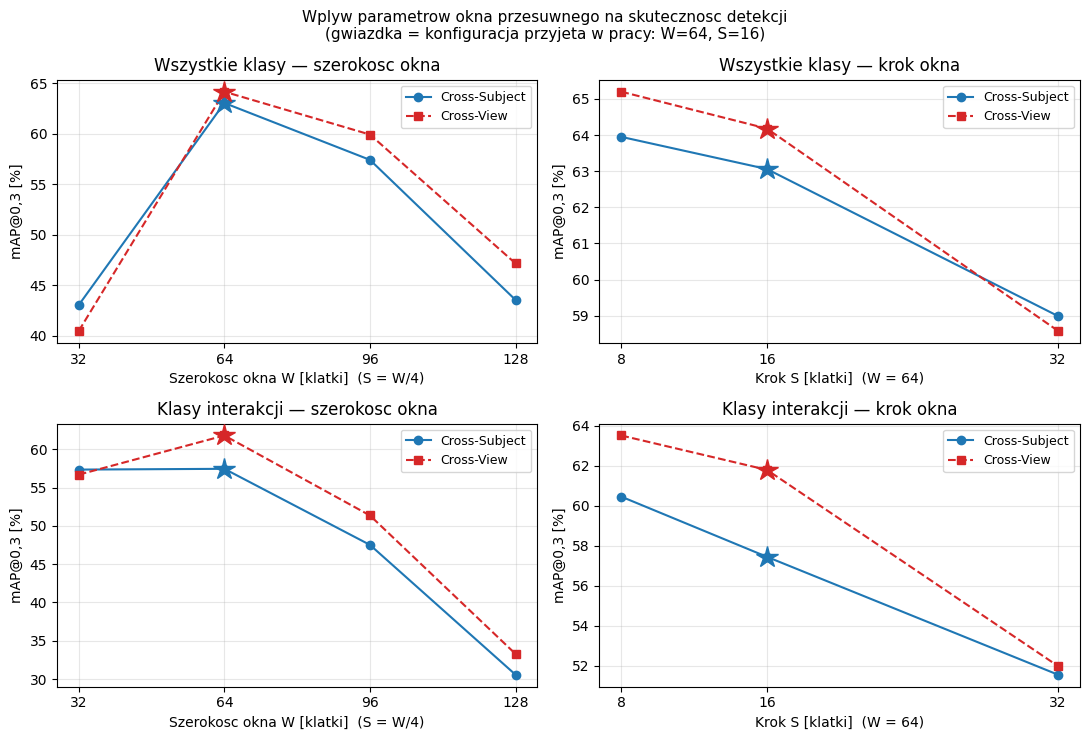

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
STYLE = {'xsub': dict(color='#1f77b4', marker='o', ls='-', label='Cross-Subject'),
         'xview': dict(color='#d62728', marker='s', ls='--', label='Cross-View')}
PLOT_SPLITS = ['xsub', 'xview']

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

panels = [
    (0, 0, 'W', 'mAP@0.3',       'Wszystkie klasy — szerokosc okna'),
    (0, 1, 'S', 'mAP@0.3',       'Wszystkie klasy — krok okna'),
    (1, 0, 'W', 'mAP@0.3_inter', 'Klasy interakcji — szerokosc okna'),
    (1, 1, 'S', 'mAP@0.3_inter', 'Klasy interakcji — krok okna'),
]

for r, c, xvar, yvar, title in panels:
    ax = axes[r, c]
    for sp in PLOT_SPLITS:
        d = df[df['split'] == sp]
        if xvar == 'W':
            sub = d[d.apply(lambda x: (x['W'], x['S']) in set(SWEEP_W), axis=1)]
        else:
            sub = d[d.apply(lambda x: (x['W'], x['S']) in set(SWEEP_S) | {(W_BEST, 16)},
                            axis=1)]
        sub = sub.sort_values(xvar)
        ax.plot(sub[xvar], sub[yvar], ms=6, **STYLE[sp])
        pick = sub[(sub['W'] == 64) & (sub['S'] == 16)]
        if len(pick):
            ax.plot(pick[xvar], pick[yvar], marker='*', ms=16, ls='none',
                    color=STYLE[sp]['color'], zorder=5)
    ax.set_xlabel('Szerokosc okna W [klatki]  (S = W/4)' if xvar == 'W'
                  else f'Krok S [klatki]  (W = {W_BEST})')
    ax.set_ylabel('mAP@0,3 [%]')
    ax.set_title(title)
    ax.set_xticks(sorted(df[df.apply(
        lambda x: (x['W'], x['S']) in (set(SWEEP_W) if xvar == 'W'
                                       else set(SWEEP_S) | {(W_BEST, 16)}), axis=1)][xvar].unique()))
    ax.legend(fontsize=9)

fig.suptitle('Wplyw parametrow okna przesuwnego na skutecznosc detekcji\n'
             '(gwiazdka = konfiguracja przyjeta w pracy: W=64, S=16)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/ablacja_okna.png', dpi=200, bbox_inches='tight')
plt.show()

## KROK 7 — Podgląd pełnej tabeli S-sweep (obie protokoły, W=64)

In [ ]:
s_sweep_view = df[(df['W'] == 64) & (df['S'].isin([8, 16, 32]))].sort_values(['split', 'S'])
display(s_sweep_view[['split', 'S', 'n_windows', 'n_detekcji', 'frame_acc',
                       'mAP@0.1', 'mAP@0.3', 'mAP@0.5',
                       'mAP@0.3_inter']].reset_index(drop=True))

,split,S,n_windows,n_detekcji,frame_acc,mAP@0.1,mAP@0.3,mAP@0.5,mAP@0.3_inter
0,xsub,8,78600,10939,56.04,73.57,63.95,45.18,60.45
1,xsub,16,39401,10602,55.57,73.04,63.06,44.32,57.44
2,xsub,32,19802,9756,53.74,70.17,58.99,35.80,51.54
3,xview,8,225771,30182,58.12,74.95,65.20,45.68,63.51
4,xview,16,113153,29177,57.69,74.23,64.18,44.09,61.79
5,xview,32,56852,26971,55.90,70.06,58.58,35.95,51.97
